# 05 — Verifica sul train/dev completi: configurazione Praat e dipendenza dal silenzio


**Input:** output del notebook 04 (`prosody_features`).

**Domande**
1. **Configurazione Praat:** `standard` o `rand18`?
2. **Silenzio ai bordi:** quanto cambia il risultato togliendo le finestre senza voce all'inizio e alla fine di ogni file
   (variante `trim`, calcolata al caricamento, senza riestrarre nulla)?

**Protocollo comune**
- training sul train completo, valutazione sul dev completo, finestre da 200 ms;
- valori estremi limitati ai percentili 0,1–99,9 (calcolati sul train, solo sulle finestre con voce), poi Min-Max sul train;
- Model A, 40 epoche fisse, 3 seed; il risultato è quello dell'**ultima epoca** (l'EER per epoca è solo informativa).

**Regole di decisione (fissate prima di vedere i risultati)**
- *Configurazione* (variante `full`): `rand18` solo se migliore su **tutti e 3 i seed** e con IC 95% bootstrap della
  differenza che esclude lo zero; altrimenti `standard`.
- *Silenzio*: si riporta la differenza `trim − full` per la configurazione scelta, con IC 95%. Non è una scelta automatica:
  serve a quantificare la dipendenza dal silenzio ai bordi.


In [1]:
import os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, PackedSequence

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/prosody_verify"))
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CONFIG_NAMES = ["standard", "rand18"]
VARIANTS = ["full", "trim"]
SEEDS = [0, 1, 2]
EPOCHS = int(os.environ.get("EPOCHS", 40))
LOG_EVERY = 5
BATCH_SIZE, LR = 32, 1e-3
CLIP_PCT = (0.1, 99.9)
N_BOOT = 1000
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
print("device:", DEVICE, "| torch", torch.__version__, f"| training previsti: {len(CONFIG_NAMES) * len(VARIANTS) * len(SEEDS)}")

device: cuda | torch 2.10.0+cu128 | training previsti: 12


In [2]:
FEAT_DIR = Path("/kaggle/input/datasets/angelopaldino/prosody-features/prosody_features")
assert (FEAT_DIR / "index.csv").exists() and (FEAT_DIR / "meta.json").exists(), f"File non trovati in {FEAT_DIR}"
index = pd.read_csv(FEAT_DIR / "index.csv").set_index("utt_id")
meta04 = json.loads((FEAT_DIR / "meta.json").read_text())
FEATURES = meta04["features"]
print("Cartella:", FEAT_DIR, "| errori di estrazione:", meta04["n_errors"])

def trim_edges(x):
    # Toglie le finestre senza voce (tutte a 0) all'inizio e alla fine; lascia almeno una finestra
    voiced = np.where(np.abs(x).sum(1) > 0)[0]
    return x[voiced[0]:voiced[-1] + 1] if len(voiced) else x[:1]

def load(name, split):
    z = np.load(FEAT_DIR / f"{name}_{split}.npz", allow_pickle=True)
    X, off, utt = z["X"], z["offsets"], z["utt_id"]
    full = [X[off[i]:off[i + 1]] for i in range(len(utt))]
    y = index.loc[utt, "y_bonafide"].to_numpy().astype(np.float32)
    attack = index.loc[utt, "attack"].to_numpy()
    return {"full": full, "trim": [trim_edges(x) for x in full], "y": y, "utt": utt, "attack": attack}

DATA = {n: {s: load(n, s) for s in ["train", "dev"]} for n in CONFIG_NAMES}
assert (DATA["standard"]["dev"]["utt"] == DATA["rand18"]["dev"]["utt"]).all()
Y_DEV, ATTACK_DEV = DATA["standard"]["dev"]["y"], DATA["standard"]["dev"]["attack"]

rows = []
for n in CONFIG_NAMES:
    for s in ["train", "dev"]:
        d = DATA[n][s]
        for v in VARIANTS:
            lens = np.array([len(x) for x in d[v]])
            zf = np.array([(np.abs(x).sum(1) == 0).mean() for x in d[v]])
            rows.append({"cfg": n, "split": s, "variant": v, "file": len(lens),
                         "finestre_mediane": np.median(lens),
                         "zero_frac_bona": zf[d["y"] == 1].mean().round(3), "zero_frac_spoof": zf[d["y"] == 0].mean().round(3)})
pd.DataFrame(rows)

Cartella: /kaggle/input/datasets/angelopaldino/prosody-features/prosody_features | errori di estrazione: 0


,cfg,split,variant,file,finestre_mediane,zero_frac_bona,zero_frac_spoof
0,standard,train,full,25380,16.0,0.426,0.298
1,standard,train,trim,25380,10.0,0.012,0.014
2,standard,dev,full,24844,16.0,0.454,0.299
3,standard,dev,trim,24844,10.0,0.013,0.014
4,rand18,train,full,25380,16.0,0.487,0.353
5,rand18,train,trim,25380,10.0,0.037,0.034
6,rand18,dev,full,24844,16.0,0.511,0.353
7,rand18,dev,trim,24844,10.0,0.038,0.035


In [3]:
def compute_eer(y, s):
    fpr, tpr, _ = roc_curve(y, s, pos_label=1)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2)

def lead_zeros(x):
    v = np.where(np.abs(x).sum(1) > 0)[0]
    return v[0] if len(v) else len(x)

def baseline(stat_tr, y_tr, stat_dv):
    sign = 1.0 if stat_tr[y_tr == 1].mean() >= stat_tr[y_tr == 0].mean() else -1.0
    return compute_eer(Y_DEV, sign * stat_dv)

base_rows = []
for n in CONFIG_NAMES:
    tr, dv = DATA[n]["train"], DATA[n]["dev"]
    for v in VARIANTS:
        zf = lambda seqs: np.array([(np.abs(x).sum(1) == 0).mean() for x in seqs])
        base_rows.append({"cfg": n, "variant": v, "statistica": "frazione finestre azzerate",
                          "eer_dev_%": round(100 * baseline(zf(tr[v]), tr["y"], zf(dv[v])), 2)})
    lz = lambda seqs: np.array([lead_zeros(x) for x in seqs], dtype=float)
    base_rows.append({"cfg": n, "variant": "full", "statistica": "finestre azzerate iniziali",
                      "eer_dev_%": round(100 * baseline(lz(tr["full"]), tr["y"], lz(dv["full"])), 2)})
BASELINES = pd.DataFrame(base_rows)
BASELINES.to_csv(OUT_DIR / "silence_baselines.csv", index=False)
BASELINES

,cfg,variant,statistica,eer_dev_%
0,standard,full,frazione finestre azzerate,32.92
1,standard,trim,frazione finestre azzerate,49.32
2,standard,full,finestre azzerate iniziali,36.33
3,rand18,full,frazione finestre azzerate,32.04
4,rand18,trim,frazione finestre azzerate,49.91
5,rand18,full,finestre azzerate iniziali,35.70


In [4]:
class ModelA(nn.Module):
    def __init__(self, n_in=len(FEATURES)):
        super().__init__()
        self.drop_in1, self.lstm1, self.bn1 = nn.Dropout(0.2), nn.LSTM(n_in, 64, batch_first=True), nn.BatchNorm1d(64)
        self.drop_in2, self.lstm2, self.bn2 = nn.Dropout(0.2), nn.LSTM(64, 32, batch_first=True), nn.BatchNorm1d(32)
        self.head = nn.Sequential(nn.Linear(32, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    @staticmethod
    def _map(p, fn):
        return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

    def forward(self, x, lengths):
        p = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(self._map(p, self.drop_in1))
        p = self._map(self._map(p, self.bn1), self.drop_in2)
        _, (h, _) = self.lstm2(p)
        return self.head(self.bn2(h[-1])).squeeze(-1)

def fit_preprocessing(train_seqs):
    allw = np.concatenate(train_seqs)
    voiced = np.abs(allw).sum(1) > 0
    clip_lo, clip_hi = np.percentile(allw[voiced], CLIP_PCT, axis=0)
    clipped = allw.copy()
    clipped[voiced] = np.clip(allw[voiced], clip_lo, clip_hi)
    lo, hi = clipped.min(0), clipped.max(0)
    rng_ = np.where(hi - lo > 0, hi - lo, 1.0)
    return {k: v.astype(np.float32) for k, v in
            {"clip_lo": clip_lo, "clip_hi": clip_hi, "minmax_lo": lo, "minmax_range": rng_}.items()}

def transform(x, pp):
    x = x.copy()
    voiced = np.abs(x).sum(1) > 0
    x[voiced] = np.clip(x[voiced], pp["clip_lo"], pp["clip_hi"])
    return (x - pp["minmax_lo"]) / pp["minmax_range"]

def to_padded(seqs, pp):
    L = torch.tensor([len(x) for x in seqs])
    B = torch.zeros(len(seqs), int(L.max()), len(FEATURES))
    for k, x in enumerate(seqs):
        B[k, :len(x)] = torch.from_numpy(transform(x, pp).astype(np.float32))
    return B, L

def predict(model, B, L, bs=512):
    model.eval(); out = []
    with torch.no_grad():
        for k in range(0, len(L), bs):
            Lk = L[k:k + bs]
            out.append(model(B[k:k + bs, :int(Lk.max())].to(DEVICE), Lk).cpu().numpy())
    return np.concatenate(out)

def run(name, variant, seed):
    tr, dv = DATA[name]["train"], DATA[name]["dev"]
    pp = fit_preprocessing(tr[variant])
    Btr, Ltr = to_padded(tr[variant], pp)
    Bdv, Ldv = to_padded(dv[variant], pp)
    torch.manual_seed(seed); np.random.seed(seed)
    model = ModelA().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    y_tr = tr["y"]
    pos_w = float((y_tr == 0).sum() / (y_tr == 1).sum())
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_w, device=DEVICE))
    ytr_t = torch.from_numpy(y_tr)
    g = np.random.default_rng(seed)
    log = []
    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = torch.from_numpy(g.permutation(len(y_tr)))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Lb = Ltr[b]
            loss = loss_fn(model(Btr[b, :int(Lb.max())].to(DEVICE), Lb), ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
        if ep % LOG_EVERY == 0 or ep == EPOCHS:
            log.append({"cfg": name, "variant": variant, "seed": seed, "epoch": ep, "loss_last": loss.item(),
                        "eer_dev": compute_eer(Y_DEV, predict(model, Bdv, Ldv))})
    return predict(model, Bdv, Ldv), log, pp

# Training e valutazione 2 configurazioni x 2 varianti x 3 seed

In [5]:
RES = OUT_DIR / "results.csv"
LOG = OUT_DIR / "training_log.csv"
rows = pd.read_csv(RES).to_dict("records") if RES.exists() else []
SCORES = {}
t_all = time.perf_counter()
for name in CONFIG_NAMES:
    for variant in VARIANTS:
        for seed in SEEDS:
            key = (name, variant, seed)
            f_scores = OUT_DIR / f"scores_{name}_{variant}_seed{seed}.npy"
            if f_scores.exists():
                SCORES[key] = np.load(f_scores)
                if not any((r["cfg"], r["variant"], r["seed"]) == key for r in rows):
                    rows.append({"cfg": name, "variant": variant, "seed": seed, "minutes": np.nan,
                                 "eer_dev": compute_eer(Y_DEV, SCORES[key])})
                continue
            t0 = time.perf_counter()
            scores, log, pp = run(name, variant, seed)
            np.save(f_scores, scores); SCORES[key] = scores
            pd.DataFrame(log).to_csv(LOG, mode="a", index=False, header=not LOG.exists())
            (OUT_DIR / f"preproc_{name}_{variant}.json").write_text(json.dumps({k: v.tolist() for k, v in pp.items()}))
            rows.append({"cfg": name, "variant": variant, "seed": seed,
                         "eer_dev": compute_eer(Y_DEV, scores), "minutes": (time.perf_counter() - t0) / 60})
            pd.DataFrame(rows).to_csv(RES, index=False)
            print(f"{name:8s} {variant:4s} seed {seed}: EER dev = {100 * rows[-1]['eer_dev']:.2f}%  ({rows[-1]['minutes']:.1f} min)")
print(f"Totale: {(time.perf_counter() - t_all) / 60:.1f} min")
res = pd.DataFrame(rows)
table = res.pivot_table(index=["cfg", "variant"], columns="seed", values="eer_dev").mul(100)
table["media"], table["std"] = table.mean(axis=1), table.std(axis=1)
table.round(2)

standard full seed 0: EER dev = 14.90%  (3.7 min)
standard full seed 1: EER dev = 15.97%  (3.6 min)
standard full seed 2: EER dev = 16.15%  (3.6 min)
standard trim seed 0: EER dev = 26.52%  (3.4 min)
standard trim seed 1: EER dev = 26.38%  (3.4 min)
standard trim seed 2: EER dev = 27.12%  (3.4 min)
rand18   full seed 0: EER dev = 15.27%  (3.5 min)
rand18   full seed 1: EER dev = 18.44%  (3.6 min)
rand18   full seed 2: EER dev = 16.45%  (3.6 min)
rand18   trim seed 0: EER dev = 23.60%  (3.4 min)
rand18   trim seed 1: EER dev = 25.75%  (3.6 min)
rand18   trim seed 2: EER dev = 24.89%  (3.7 min)
Totale: 42.5 min


seed                  0      1      2  media   std
cfg      variant                                  
rand18   full     15.27  18.44  16.45  16.72  1.60
         trim     23.60  25.75  24.89  24.75  1.08
standard full     14.90  15.97  16.15  15.67  0.68
         trim     26.52  26.38  27.12  26.67  0.39

In [6]:
def paired_bootstrap(s_a, s_b, n_boot=N_BOOT, seed=0):
    # IC 95% di EER(a) - EER(b), ricampionando i file del dev per classe
    g = np.random.default_rng(seed)
    ib, is_ = np.where(Y_DEV == 1)[0], np.where(Y_DEV == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(Y_DEV[ii], s_a[ii]) - compute_eer(Y_DEV[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

avg = {(n, v): np.mean([SCORES[(n, v, s)] for s in SEEDS], axis=0) for n in CONFIG_NAMES for v in VARIANTS}

per_seed = res[res["variant"] == "full"].pivot(index="seed", columns="cfg", values="eer_dev") * 100
per_seed["standard_meno_rand18"] = per_seed["standard"] - per_seed["rand18"]
display(per_seed.round(2))
ci_cfg = paired_bootstrap(avg[("standard", "full")], avg[("rand18", "full")])
better_all = bool((per_seed["standard_meno_rand18"] > 0).all())
CHOICE = "rand18" if (better_all and ci_cfg[0] > 0) else "standard"
print(f"EER (punteggio medio sui seed): standard {100 * compute_eer(Y_DEV, avg[('standard', 'full')]):.2f}% | "
      f"rand18 {100 * compute_eer(Y_DEV, avg[('rand18', 'full')]):.2f}%")
print(f"Differenza standard - rand18, IC 95%: [{ci_cfg[0]:.2f}, {ci_cfg[1]:.2f}] punti | rand18 migliore su tutti i seed: {better_all}")
print(f"\n==> Configurazione scelta: {CHOICE}")

cfg,rand18,standard,standard_meno_rand18
seed,,,
0,15.27,14.90,-0.37
1,18.44,15.97,-2.47
2,16.45,16.15,-0.29


EER (punteggio medio sui seed): standard 15.14% | rand18 15.64%
Differenza standard - rand18, IC 95%: [-1.18, 0.08] punti | rand18 migliore su tutti i seed: False

==> Configurazione scelta: standard


In [7]:
per_seed_t = res[res["cfg"] == CHOICE].pivot(index="seed", columns="variant", values="eer_dev") * 100
per_seed_t["trim_meno_full"] = per_seed_t["trim"] - per_seed_t["full"]
display(per_seed_t.round(2))
ci_trim = paired_bootstrap(avg[(CHOICE, "trim")], avg[(CHOICE, "full")])
print(f"{CHOICE}: EER full {100 * compute_eer(Y_DEV, avg[(CHOICE, 'full')]):.2f}% | "
      f"trim {100 * compute_eer(Y_DEV, avg[(CHOICE, 'trim')]):.2f}%")
print(f"Differenza trim - full, IC 95%: [{ci_trim[0]:.2f}, {ci_trim[1]:.2f}] punti "
      "(positiva = togliere il silenzio ai bordi peggiora il risultato)")

variant,full,trim,trim_meno_full
seed,,,
0,14.90,26.52,11.62
1,15.97,26.38,10.41
2,16.15,27.12,10.97


standard: EER full 15.14% | trim 25.71%
Differenza trim - full, IC 95%: [9.59, 11.58] punti (positiva = togliere il silenzio ai bordi peggiora il risultato)


In [8]:
att_rows = []
for v in VARIANTS:
    s = avg[(CHOICE, v)]
    r = {"variant": v}
    for a in sorted(set(ATTACK_DEV) - {"bonafide"}):
        m = (ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)
        r[a] = round(100 * compute_eer(Y_DEV[m], s[m]), 2)
    att_rows.append(r)
per_attack = pd.DataFrame(att_rows).set_index("variant")
per_attack.to_csv(OUT_DIR / "eer_per_attack.csv")
per_attack

,A01,A02,A03,A04,A05,A06
variant,,,,,,
full,0.37,12.32,0.52,0.34,24.10,24.04
trim,14.41,4.17,19.41,39.15,24.49,40.40


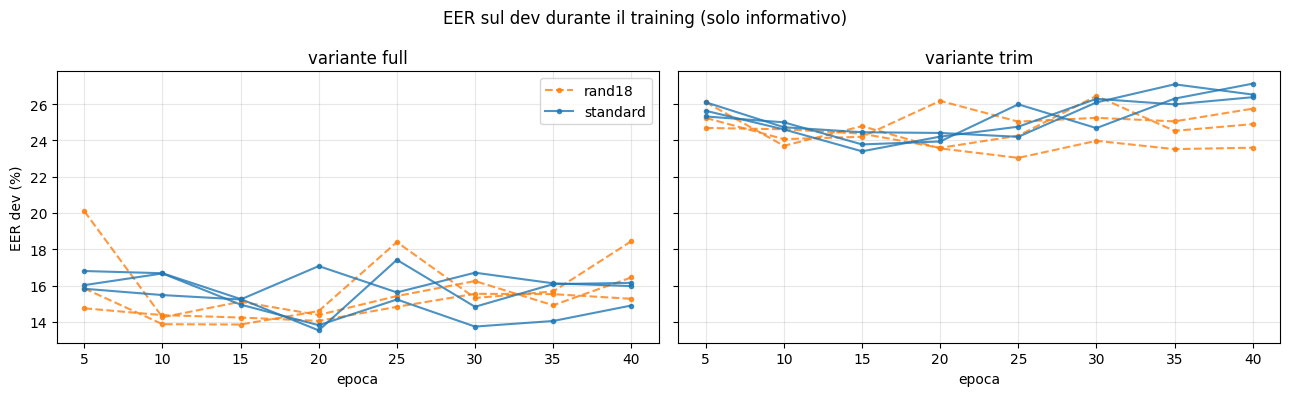

Output: ['decision.json', 'dev_curves.png', 'eer_per_attack.csv', 'preproc_rand18_full.json', 'preproc_rand18_trim.json', 'preproc_standard_full.json', 'preproc_standard_trim.json', 'results.csv', 'scores_rand18_full_seed0.npy', 'scores_rand18_full_seed1.npy', 'scores_rand18_full_seed2.npy', 'scores_rand18_trim_seed0.npy', 'scores_rand18_trim_seed1.npy', 'scores_rand18_trim_seed2.npy', 'scores_standard_full_seed0.npy', 'scores_standard_full_seed1.npy', 'scores_standard_full_seed2.npy', 'scores_standard_trim_seed0.npy', 'scores_standard_trim_seed1.npy', 'scores_standard_trim_seed2.npy', 'silence_baselines.csv', 'training_log.csv']


In [9]:
lg = pd.read_csv(LOG)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, v in zip(axes, VARIANTS):
    for (n, s), d in lg[lg["variant"] == v].groupby(["cfg", "seed"]):
        ax.plot(d["epoch"], 100 * d["eer_dev"], marker=".", ls="-" if n == "standard" else "--",
                color="C0" if n == "standard" else "C1", alpha=0.8, label=n if s == 0 else None)
    ax.set_title(f"variante {v}"); ax.set_xlabel("epoca"); ax.grid(alpha=0.3)
axes[0].set_ylabel("EER dev (%)"); axes[0].legend()
plt.suptitle("EER sul dev durante il training (solo informativo)")
plt.tight_layout(); plt.savefig(OUT_DIR / "dev_curves.png", dpi=120); plt.show()

decision = {"choice_config": CHOICE, "rule_config": "rand18 se migliore su tutti i seed e IC95 esclude 0",
            "config_ci95_std_minus_rand18": ci_cfg.tolist(), "rand18_better_all_seeds": better_all,
            "trim_minus_full_ci95": ci_trim.tolist(), "eer_table_%": table.round(3).reset_index().to_dict("records"),
            "eer_per_attack_%": per_attack.reset_index().to_dict("records"),
            "silence_baselines": BASELINES.to_dict("records"),
            "epochs": EPOCHS, "lr": LR, "batch_size": BATCH_SIZE, "clip_pct": CLIP_PCT, "device": DEVICE}
_ = (OUT_DIR / "decision.json").write_text(json.dumps(decision, indent=2, default=str))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir()))